# Quick Start: Surface To Yamada

This notebook is one chapter of the runnable `KnottedGraph` user guide.  It is
generated into `User_guide/01_quick_start.ipynb` so users can open the specific workflow
they need without navigating one very large notebook.

- self-contained after the shared setup cells


## 0. Setup, Preflight, And Shared Plot Style

The whole notebook uses the same visual convention:

- blue: surfaces, skeleton points, and graph edges;
- red: graph vertices;
- black axes;
- paper notation: `Upsilon(G; Y)`.

The helper functions in this section remove repeated plotting boilerplate from
the rest of the notebook.  This is also the library-level pattern worth
promoting later into public visualization helpers.


In [1]:
from pathlib import Path
import sys
import importlib.util
import os
import tempfile

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DOC_ROOT = PROJECT_ROOT / "doc"
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "knottedgraph-mpl"))

print("project paths configured")
for package in ["numpy", "networkx", "sympy", "plotly", "matplotlib", "pyvista"]:
    print(f"{package:10s} = {importlib.util.find_spec(package) is not None}")


project paths configured
numpy      = True
networkx   = True
sympy      = True
plotly     = True
matplotlib = True
pyvista    = True


In [2]:
import math
import time

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import sympy as sp
from IPython.display import Math, display

from knotted_graph.projection import (
    compute_yamada_polynomial,
    sample_projections,
    select_projection,
)
from knotted_graph.visualization import plot_3D_graph_plotly

BLUE = "#1f77b4"
RED = "#d62728"
CAMERA = dict(eye=dict(x=1.45, y=1.55, z=1.18))
pio.renderers.default = "notebook_connected"
Y = sp.Symbol("Y")
kx, ky, kz = sp.symbols("k_x k_y k_z", real=True)


def axis_style():
    return dict(
        visible=True,
        title="",
        showticklabels=False,
        showbackground=False,
        showgrid=False,
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=2,
    )


def apply_kg_layout(fig, *, width=760, height=620):
    fig.update_layout(
        title=None,
        width=width,
        height=height,
        margin=dict(l=0, r=0, t=0, b=0),
        scene=dict(
            xaxis=axis_style(),
            yaxis=axis_style(),
            zaxis=axis_style(),
            aspectmode="data",
            camera=CAMERA,
        ),
    )
    return fig


def plot_surface_polydata(surface, *, opacity=0.58):
    mesh = surface.triangulate()
    faces = mesh.faces.reshape(-1, 4)[:, 1:]
    pts = mesh.points
    fig = go.Figure(
        go.Mesh3d(
            x=pts[:, 0],
            y=pts[:, 1],
            z=pts[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            color=BLUE,
            opacity=opacity,
        )
    )
    return apply_kg_layout(fig)


def plot_points_3d(points, *, size=3):
    points = np.asarray(points)
    fig = go.Figure(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker=dict(size=size, color=BLUE),
        )
    )
    return apply_kg_layout(fig)


def plot_graph_kg(graph):
    return apply_kg_layout(plot_3D_graph_plotly(graph))


def print_upsilon(label, expr):
    print(f"Upsilon({label}; Y) = {sp.expand(expr)}")


def display_bloch_vector(label, components):
    display(Math(label + r"=" + sp.latex(sp.Matrix(components))))


print("shared plotting and notation helpers ready")


shared plotting and notation helpers ready


## 1. Minimal Pipeline: Surface To Spatial Graph To `Upsilon(G;Y)`

This section is the first ten-minute demonstration of the whole library.  The
example is a synthetic tube surface whose spine is a trivalent K4-type
spatial graph.  It is intentionally richer than a toy loop: it has four real
branch vertices, six edges, nontrivial projection crossings, and a nonconstant
Yamada polynomial.


In [3]:
def trivalent_k4_spine(samples=90, amplitude=0.75):
    vertices = {
        "a": np.array([-1.15, -0.78, -0.38]),
        "b": np.array([1.18, -0.64, 0.30]),
        "c": np.array([0.86, 0.95, -0.26]),
        "d": np.array([-0.88, 0.84, 0.52]),
    }
    edge_specs = [
        ("a", "b", "ab", np.array([0.00, 0.90, 0.70]), 0.0),
        ("a", "c", "ac", np.array([0.35, -0.15, 1.00]), 1.1),
        ("a", "d", "ad", np.array([0.95, 0.15, -0.25]), 2.2),
        ("b", "c", "bc", np.array([-0.90, 0.25, 0.35]), 0.7),
        ("b", "d", "bd", np.array([-0.20, 1.00, -0.60]), 1.7),
        ("c", "d", "cd", np.array([0.10, -0.90, -0.85]), 2.8),
    ]

    s = np.linspace(0.0, 1.0, samples)
    graph = nx.MultiGraph()
    for vertex_id, pos in vertices.items():
        graph.add_node(vertex_id, pos=pos)

    for u, v, key, bend, phase in edge_specs:
        start = vertices[u]
        end = vertices[v]
        chord = end - start
        bend = bend / np.linalg.norm(bend)
        side = np.cross(chord, bend)
        side = side / np.linalg.norm(side)
        envelope = np.sin(np.pi * s)
        pts = (1 - s)[:, None] * start + s[:, None] * end
        pts += amplitude * envelope[:, None] * (
            np.cos(phase + np.pi * s)[:, None] * bend
            + 0.6 * np.sin(2 * np.pi * s + phase)[:, None] * side
        )
        pts[0] = start
        pts[-1] = end
        graph.add_edge(u, v, key=key, pts=pts)

    graph.graph.update(
        graph_id="paper_companion_trivalent_k4",
        input_kind="synthetic_surface_spine",
        is_closed=True,
    )
    return graph


def tube_patch(points, radius=0.11, sides=28):
    tangents = np.gradient(points, axis=0)
    tangents = tangents / np.linalg.norm(tangents, axis=1, keepdims=True)
    reference = np.tile(np.array([0.0, 0.0, 1.0]), (len(points), 1))
    nearly_parallel = np.abs(np.sum(tangents * reference, axis=1)) > 0.92
    reference[nearly_parallel] = np.array([0.0, 1.0, 0.0])
    normals = np.cross(tangents, reference)
    normals = normals / np.linalg.norm(normals, axis=1, keepdims=True)
    binormals = np.cross(tangents, normals)

    theta = np.linspace(0.0, 2 * np.pi, sides, endpoint=True)
    circle = (
        np.cos(theta)[None, :, None] * normals[:, None, :]
        + np.sin(theta)[None, :, None] * binormals[:, None, :]
    )
    tube = points[:, None, :] + radius * circle
    return {"x": tube[:, :, 0], "y": tube[:, :, 1], "z": tube[:, :, 2]}


def sphere_patch(center, radius=0.18, samples=28):
    phi = np.linspace(0.0, np.pi, samples)
    theta = np.linspace(0.0, 2 * np.pi, samples)
    phi, theta = np.meshgrid(phi, theta, indexing="ij")
    return {
        "x": center[0] + radius * np.sin(phi) * np.cos(theta),
        "y": center[1] + radius * np.sin(phi) * np.sin(theta),
        "z": center[2] + radius * np.cos(phi),
    }


def trivalent_k4_surface_graph(tube_radius=0.12):
    graph = trivalent_k4_spine()
    tube_surfaces = [
        tube_patch(data["pts"], radius=tube_radius)
        for _, _, data in graph.edges(data=True)
    ]
    vertex_surfaces = [
        sphere_patch(data["pos"], radius=1.45 * tube_radius)
        for _, data in graph.nodes(data=True)
    ]
    return tube_surfaces, vertex_surfaces, graph


tube_surfaces, vertex_surfaces, graph = trivalent_k4_surface_graph()
print(f"surface tube patches = {len(tube_surfaces)}")
print(f"surface vertex patches = {len(vertex_surfaces)}")
print(f"nodes_edges = {(graph.number_of_nodes(), graph.number_of_edges())}")
print(f"degrees = {dict(graph.degree())}")


surface tube patches = 6
surface vertex patches = 4
nodes_edges = (4, 6)
degrees = {'a': 3, 'b': 3, 'c': 3, 'd': 3}


In [4]:
fig = go.Figure()
for patch in tube_surfaces:
    fig.add_trace(
        go.Surface(
            x=patch["x"],
            y=patch["y"],
            z=patch["z"],
            surfacecolor=np.zeros_like(patch["x"]),
            colorscale=[[0, BLUE], [1, BLUE]],
            showscale=False,
            opacity=0.42,
        )
    )
for patch in vertex_surfaces:
    fig.add_trace(
        go.Surface(
            x=patch["x"],
            y=patch["y"],
            z=patch["z"],
            surfacecolor=np.zeros_like(patch["x"]),
            colorscale=[[0, RED], [1, RED]],
            showscale=False,
            opacity=0.92,
        )
    )
apply_kg_layout(fig).show()


The surface is the finite-thickness geometric object.  The red balls are real
branch neighborhoods: each is incident to three blue tube pieces, so the spine
has genuine trivalent graph vertices.


In [5]:
fig = plot_graph_kg(graph)
fig.show()


In [6]:
projection = select_projection(graph, rotation_angles=(0.0, 0.0, 0.0))
print(f"rotation_angles = {tuple(round(a, 2) for a in projection.rotation_angles)}")
print(f"crossings = {projection.num_crossings}")
print(f"pd_code = {projection.pd_code}")


rotation_angles = (0.0, 0.0, 0.0)
crossings = 5
pd_code = V[2,0,7];V[1,9,10];V[6,9,13];V[12,8,15];X[11,8,12,7];X[14,5,15,4];X[1,3,0,2];X[10,4,11,3];X[14,6,13,5]


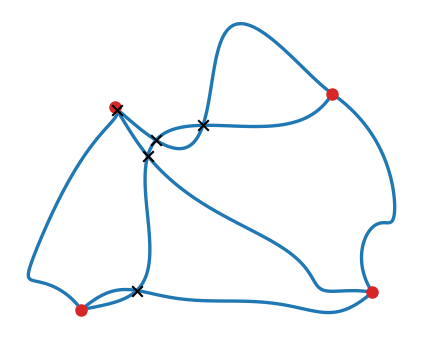

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.2, 4.4))
for arc in projection.arcs:
    ax.plot(*arc.line.xy, color=BLUE, linewidth=2.4)
for vertex in projection.vertices:
    ax.scatter(*vertex.point.xy, color=RED, s=64, zorder=3)
for crossing in projection.crossings:
    ax.scatter(*crossing.point.xy, marker="x", color="black", s=58, zorder=4)
ax.set_aspect("equal")
ax.axis("off")
plt.show()


In [8]:
Y = sp.Symbol("Y")
result = compute_yamada_polynomial(
    graph,
    Y,
    rotation_angles=projection.rotation_angles,
    return_result=True,
    n_jobs=1,
)
print_upsilon("G", result.polynomial)
print(f"selected crossings = {result.projection.num_crossings}")


Upsilon(G; Y) = -Y**6 - 2*Y**4 - 2*Y**2 - 1
selected crossings = 5


The output is the first complete library demonstration.  Geometry is no longer
needed after the PD code is built; the invariant calculation uses the symbolic
diagrammatic data.
